In [ ]:
import os
os.chdir('/home/bjaha/Documents/RL-catalyst/nat-com-test')

import time
from dataclasses import dataclass
from pathlib import Path
from typing import List, Dict, Tuple

from tqdm import tqdm
import numpy as np
import pandas as pd

from PIL import Image, ImageDraw, ImageFont
from ase import Atoms
from ase.io import read

from src.performance.energetics import XTBOptimizer, EnergyUnit
from src.performance.reward_metrics_rings import get_max_view_positions

from scripts.analyse.exp5_scaffold.visuals.visualize import (
    submit_job,
    filter_data,
    find_candidate_mols,
)


In [ ]:
def get_data_folder(base_dir: str, data_folder: str, formula: str) -> Path:
    return Path(f'{base_dir}/results/{data_folder}/{formula}')



def get_all_dfs(base_dir: str, eval_formulas: List[str], data_folder: str) -> Dict[str, pd.DataFrame]:
    dfs = {}
    trajs = {}

    for formula in tqdm(eval_formulas, desc='Loading data'):
        dfs[formula] = []
        trajs[formula] = []

        # Load metrics
        formula_folder_path = get_data_folder(base_dir, data_folder, formula)
        print(formula_folder_path)
        existing_path = formula_folder_path if formula_folder_path.exists() else None

        if not existing_path:
            print(f'Missing path for {formula}')
            continue

        # load df
        df = pd.read_csv(os.path.join(existing_path, 'df.csv'))
        dfs[formula].append(df)


        # load atoms.traj
        atoms_traj_path = os.path.join(existing_path, 'atoms.traj')
        atoms_list = read(atoms_traj_path, index=':')
        trajs[formula].extend(atoms_list)


    all_dfs = {formula: pd.concat(dfs[formula]).reset_index(drop=True) for formula in eval_formulas}

    return all_dfs, trajs


def select_best_mols(
    dfs_filtered: Dict[str, pd.DataFrame],
    trajs_filtered: Dict[str, List[Atoms]],
    eval_formulas: List[str],
    n_mols: int
) -> Tuple[Dict[str, List[Atoms]], Dict[str, pd.DataFrame]]:
    """ Just select the best n_mols of each formula, according to the sorting_key. """
    best_mols = {}
    best_df = {}
    for formula in eval_formulas:
        best_mols[formula] = trajs_filtered[formula][:n_mols]
        best_df[formula] = dfs_filtered[formula].iloc[:n_mols]
    return best_mols, best_df


@dataclass
class Molecule:
    smiles: str
    abs_energy: float
    e_relaxed_f10: float
    e_relaxed_f5: float
    dipole_relaxed_f5: float
    atoms: Atoms

@dataclass
class AgentData:
    tag: str
    visuals_dir: str
    save_dir: str
    top_k: Dict[str, List[Molecule]]
    all_dfs: Dict[str, pd.DataFrame]
    all_trajs: Dict[str, List[Atoms]]



def optimize_and_sort_mols(
    best_trajs: Dict[str, List[Atoms]],
    best_df: Dict[str, pd.DataFrame],
    eval_formulas: List[str],
    smiles_col: str
) -> Dict[str, List[Molecule]]:
    calc = XTBOptimizer(method='GFN2-xTB', energy_unit=EnergyUnit.EV, use_mp=False)


    sorted_candidates = {}
    for formula in tqdm(eval_formulas, desc='Optimizing and sorting molecules'):
        e_relaxed = []
        m_relaxed = []
        dipole_relaxed = []
        for mol in tqdm(best_trajs[formula], desc='Relaxing molecules'):
            opt_info = calc.optimize_atoms(mol, max_steps=1000, fmax=0.05, redirect_logfile=False)
            m_relaxed.append(opt_info['new_atoms'])
            e_relaxed.append(opt_info['energy_after'])
            dipole = calc.calc_dipole(opt_info['new_atoms'])
            dipole = dipole if dipole is not None else 0.0
            dipole_relaxed.append(dipole)

        # Sort based on relaxed dipole (largest first)
        arange = np.arange(len(dipole_relaxed))
        idx, _ = zip(*sorted(zip(arange, dipole_relaxed), key=lambda pair: pair[1], reverse=True))
        
        sorted_candidates[formula] = []
        for i in range(len(e_relaxed)):
            sorted_candidates[formula].append(
                Molecule(
                    smiles=best_df[formula].iloc[idx[i]][smiles_col],
                    abs_energy=best_df[formula].iloc[idx[i]]['abs_energy'],
                    e_relaxed_f10=best_df[formula].iloc[idx[i]]['e_relaxed'],
                    e_relaxed_f5=e_relaxed[idx[i]],
                    dipole_relaxed_f5=dipole_relaxed[idx[i]],
                    atoms=m_relaxed[idx[i]]
                )
            )
        

    return sorted_candidates



def rotate_mols(mols: Dict[str, List[Atoms]]) -> Dict[str, List[Atoms]]:
    """ Rotate of the molecule to get a better view. """
    for formula, mols_to_view in mols.items():
        for mol in mols_to_view:
            mol.set_positions(get_max_view_positions(mol.get_positions()))


def launch_chimerax_jobs(mols_to_view: Dict[str, List[Atoms]], save_dir: str, bg_color_str: str):
    rotate_mols(mols_to_view)

    formulas = list(mols_to_view.keys())

    for formula in formulas:
        mols = mols_to_view[formula]

        # Finally, write molecules to pdb and create Chimerax visualization (png).
        pdb_paths = [os.path.join(save_dir, f'{formula}_{i}.pdb') for i in range(len(mols))]
        png_paths = [os.path.join(save_dir, f'{formula}_{i}.png') for i in range(len(mols))]


        # Write molecules to pdb.
        for i, mol in enumerate(mols):
            mol.write(pdb_paths[i])

        # Create Chimerax visualization (png).
        for i, (pdb_path, png_path) in enumerate(zip(pdb_paths, png_paths)):
            params = {
                "pdb_path": os.path.join(os.getcwd(), pdb_path),
                "image_path": os.path.join(os.getcwd(), png_path),
                "movie_path": None,
                "atoms_to_deselect": [], # 0, 1, 2, 3]
                "selected_action": "",
                "bg_color": bg_color_str
            }

            print(f"params: {params}")
            submit_job(params)

    return



def default_eval_formulas() -> List[str]:
    return [
        'H4C3O3',  # Bad
        'H6C3O3',  # Good
        'H6C4O3',  # Bad
        'H8C4O3',  # Good
        'H6C5O3',  # Bad
        'H8C5O3',  # Bad
        'H10C5O3', # Good
    ]

import re
def build_eval_formulas_pretty() -> List[str]:
    formulas = default_eval_formulas()
    # In the text string, flip the order of hydrogens and carbon to match convention. 
    # Remember their counts as well. 
    # Use regex to do this.
    
    pretty_formulas = []
    for formula in formulas:
        # Use regex to find matches for element+count, e.g., H4, C3, O3
        matches = re.findall(r'([A-Z][a-z]*)(\d+)', formula)
        # We'll reorder so that C comes first, then H, then anything else alphabetically
        # Build a dict
        elem_dict = {elem: int(count) for elem, count in matches}
        order = ['C', 'H'] + sorted([e for e in elem_dict.keys() if e not in ('C', 'H')])
        # Only include element if present
        pretty = ''.join(f'{e}{elem_dict[e]}' for e in order if e in elem_dict)
        pretty_formulas.append(pretty)
    
    return pretty_formulas




In [3]:


# Define the experiment parameters
base_dir = 'pretrain_runs/A-30k-Fixed/seed_0'
tag = 'EXP5_30000'
n_seeds = 1
model_names = {
    "30000": {
        "data_folder": "tuesday-30k-dip-30000",
        "model_obj": "pretrain_run-0_steps-30000.model",
        "visuals_dir": "exp5_black_dipole_tuesday-30k-dip-30000"
    },
    "35000": {
        "data_folder": "tuesday-30k-dip-30500",
        "model_obj": "pretrain_run-0_steps-30500.model",
        "visuals_dir": "exp5_black_dipole_tuesday-30k-dip-30500"
    }
}
eval_formulas = default_eval_formulas()


stratify_on_smiles = True # absolutely necessary
bg_color_str = 'black'
show_relaxed = True

# Which molecules to view?
search_for_candidates = False
n_query = None # n_mols matching the query
n_non_query = None # n_mols not matching the query
n_mols = 3 # Number of molecules to view of each formula


sorting_key = 'dipole'
smiles_col = 'SMILES' if show_relaxed else 'NEW_SMILES'

# Create save directory
illustration_dir_name = f'exp5_grid_figure'

save_dir = os.path.join(base_dir, illustration_dir_name)
if not os.path.exists(save_dir):
    os.makedirs(save_dir)


In [4]:


results = {}
for model_name in model_names:
    model_data_folder = model_names[model_name]['data_folder']

    # Get all data
    start_time = time.time()
    all_dfs, trajs = get_all_dfs(base_dir, eval_formulas, model_data_folder)
    print(f"a) Time taken to get all data: {time.time() - start_time} seconds")


    # Filter data
    start_time = time.time()
    dfs_filtered, trajs_filtered = filter_data(
        all_dfs, 
        trajs, 
        eval_formulas, 
        sorting_key, 
        smiles_col, 
        stratify_on_smiles
    )
    print(f"b) Time taken to filter data: {time.time() - start_time} seconds")



    # Find candidate molecules
    if search_for_candidates:
        best_trajs, best_df = find_candidate_mols(dfs_filtered, trajs_filtered, eval_formulas, n_query, n_non_query)
    else:
        best_trajs, best_df = select_best_mols(dfs_filtered, trajs_filtered, eval_formulas, n_mols)

    for formula in best_trajs:
        print(f"Number of molecules for {formula}: {len(best_trajs[formula])}")
    

    if show_relaxed:
        # Optimize and sort molecules
        sorted_candidates = optimize_and_sort_mols(best_trajs, best_df, eval_formulas, smiles_col)
    else:
        mols_to_view = best_trajs
        energies_relaxed = None

    # Save images
    # launch_chimerax_jobs(mols_to_view, save_dir, bg_color_str)



    results[model_name] = AgentData(
        tag=model_name,
        visuals_dir=model_names[model_name]['visuals_dir'],
        save_dir=model_data_folder,
        top_k=sorted_candidates,
        all_dfs=all_dfs,
        all_trajs=trajs,
    )



Loading data:  43%|████▎     | 3/7 [00:00<00:00, 20.42it/s]

pretrain_runs/A-30k-Fixed/seed_0/results/tuesday-30k-dip-30000/H4C3O3
pretrain_runs/A-30k-Fixed/seed_0/results/tuesday-30k-dip-30000/H6C3O3
pretrain_runs/A-30k-Fixed/seed_0/results/tuesday-30k-dip-30000/H6C4O3
pretrain_runs/A-30k-Fixed/seed_0/results/tuesday-30k-dip-30000/H8C4O3
pretrain_runs/A-30k-Fixed/seed_0/results/tuesday-30k-dip-30000/H6C5O3


Loading data: 100%|██████████| 7/7 [00:00<00:00, 16.94it/s]


pretrain_runs/A-30k-Fixed/seed_0/results/tuesday-30k-dip-30000/H8C5O3
pretrain_runs/A-30k-Fixed/seed_0/results/tuesday-30k-dip-30000/H10C5O3
a) Time taken to get all data: 0.436356782913208 seconds
b) Time taken to filter data: 0.03338027000427246 seconds
Number of molecules for H4C3O3: 3
Number of molecules for H6C3O3: 3
Number of molecules for H6C4O3: 3
Number of molecules for H8C4O3: 3
Number of molecules for H6C5O3: 3
Number of molecules for H8C5O3: 3
Number of molecules for H10C5O3: 3


Loading data:  29%|██▊       | 2/7 [00:00<00:00, 14.28it/s]

...

Loading data:  57%|█████▋    | 4/7 [00:00<00:00, 13.98it/s]

pretrain_runs/A-30k-Fixed/seed_0/results/tuesday-30k-dip-30500/H8C4O3
pretrain_runs/A-30k-Fixed/seed_0/results/tuesday-30k-dip-30500/H6C5O3
pretrain_runs/A-30k-Fixed/seed_0/results/tuesday-30k-dip-30500/H8C5O3


Loading data: 100%|██████████| 7/7 [00:00<00:00, 13.52it/s]


pretrain_runs/A-30k-Fixed/seed_0/results/tuesday-30k-dip-30500/H10C5O3
a) Time taken to get all data: 0.5296783447265625 seconds
b) Time taken to filter data: 0.0257108211517334 seconds
Number of molecules for H4C3O3: 3
Number of molecules for H6C3O3: 3
Number of molecules for H6C4O3: 3
Number of molecules for H8C4O3: 3
Number of molecules for H6C5O3: 3
Number of molecules for H8C5O3: 3
Number of molecules for H10C5O3: 3


Optimizing and sorting molecules: 100%|██████████| 7/7 [00:29<00:00,  4.18s/it]


plot_histograms() took 6.75 seconds
plot_molecules() took 2.61 seconds
draw_outer_box() took 0.00 seconds
write_agent_names() took 0.00 seconds
save_image_grid() took 2.70 seconds


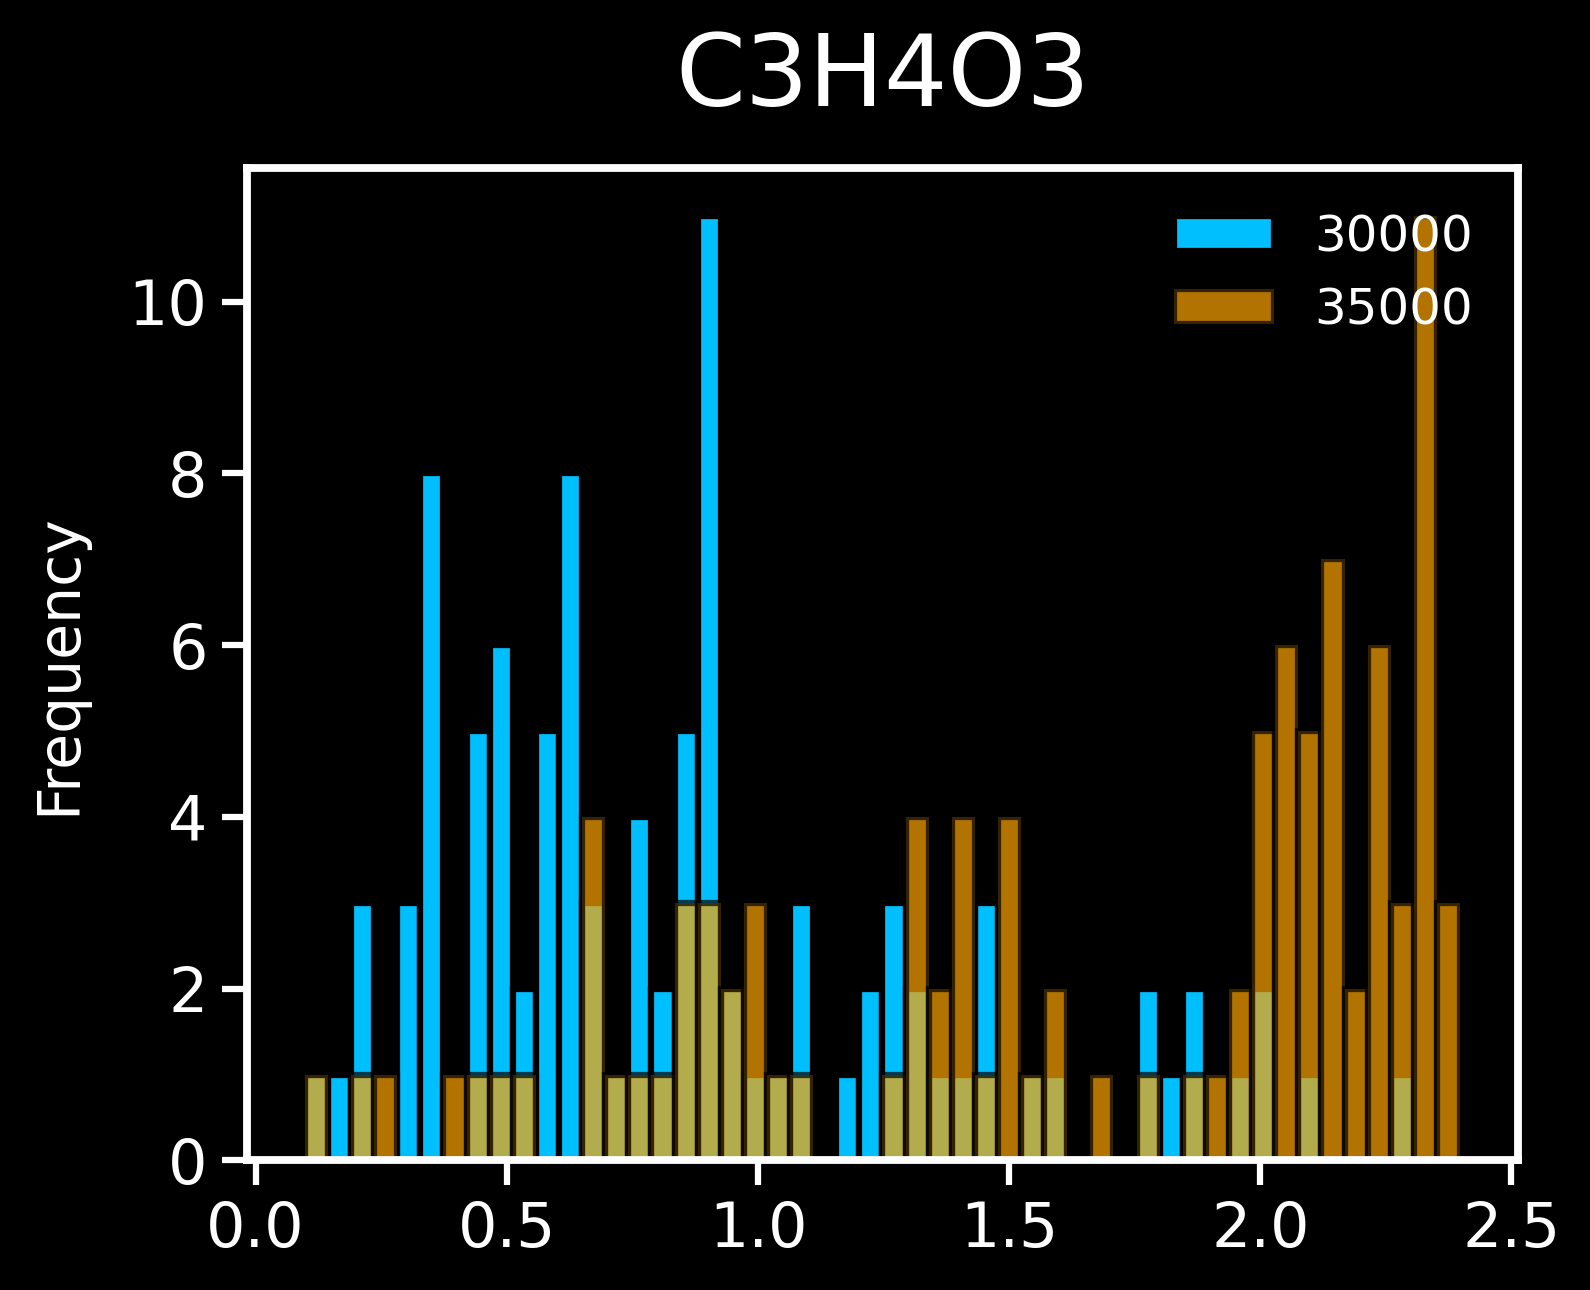

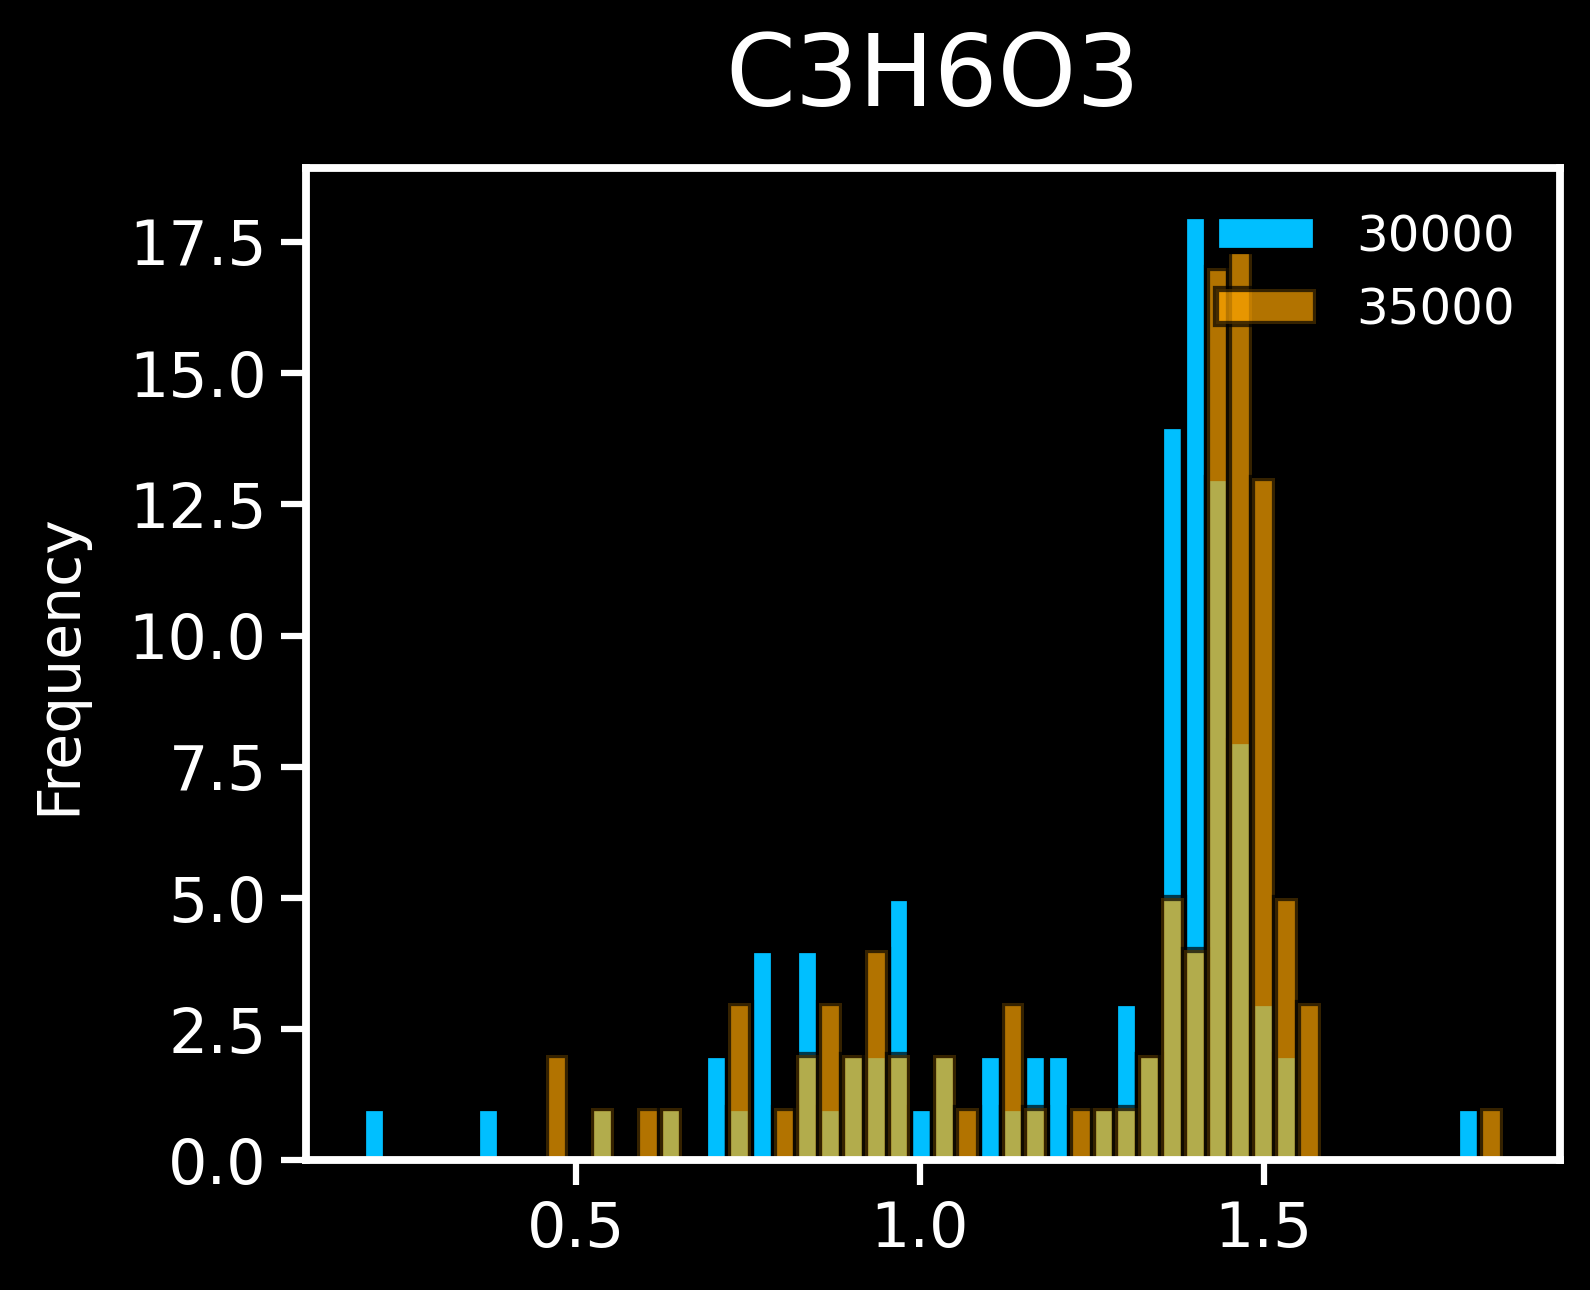

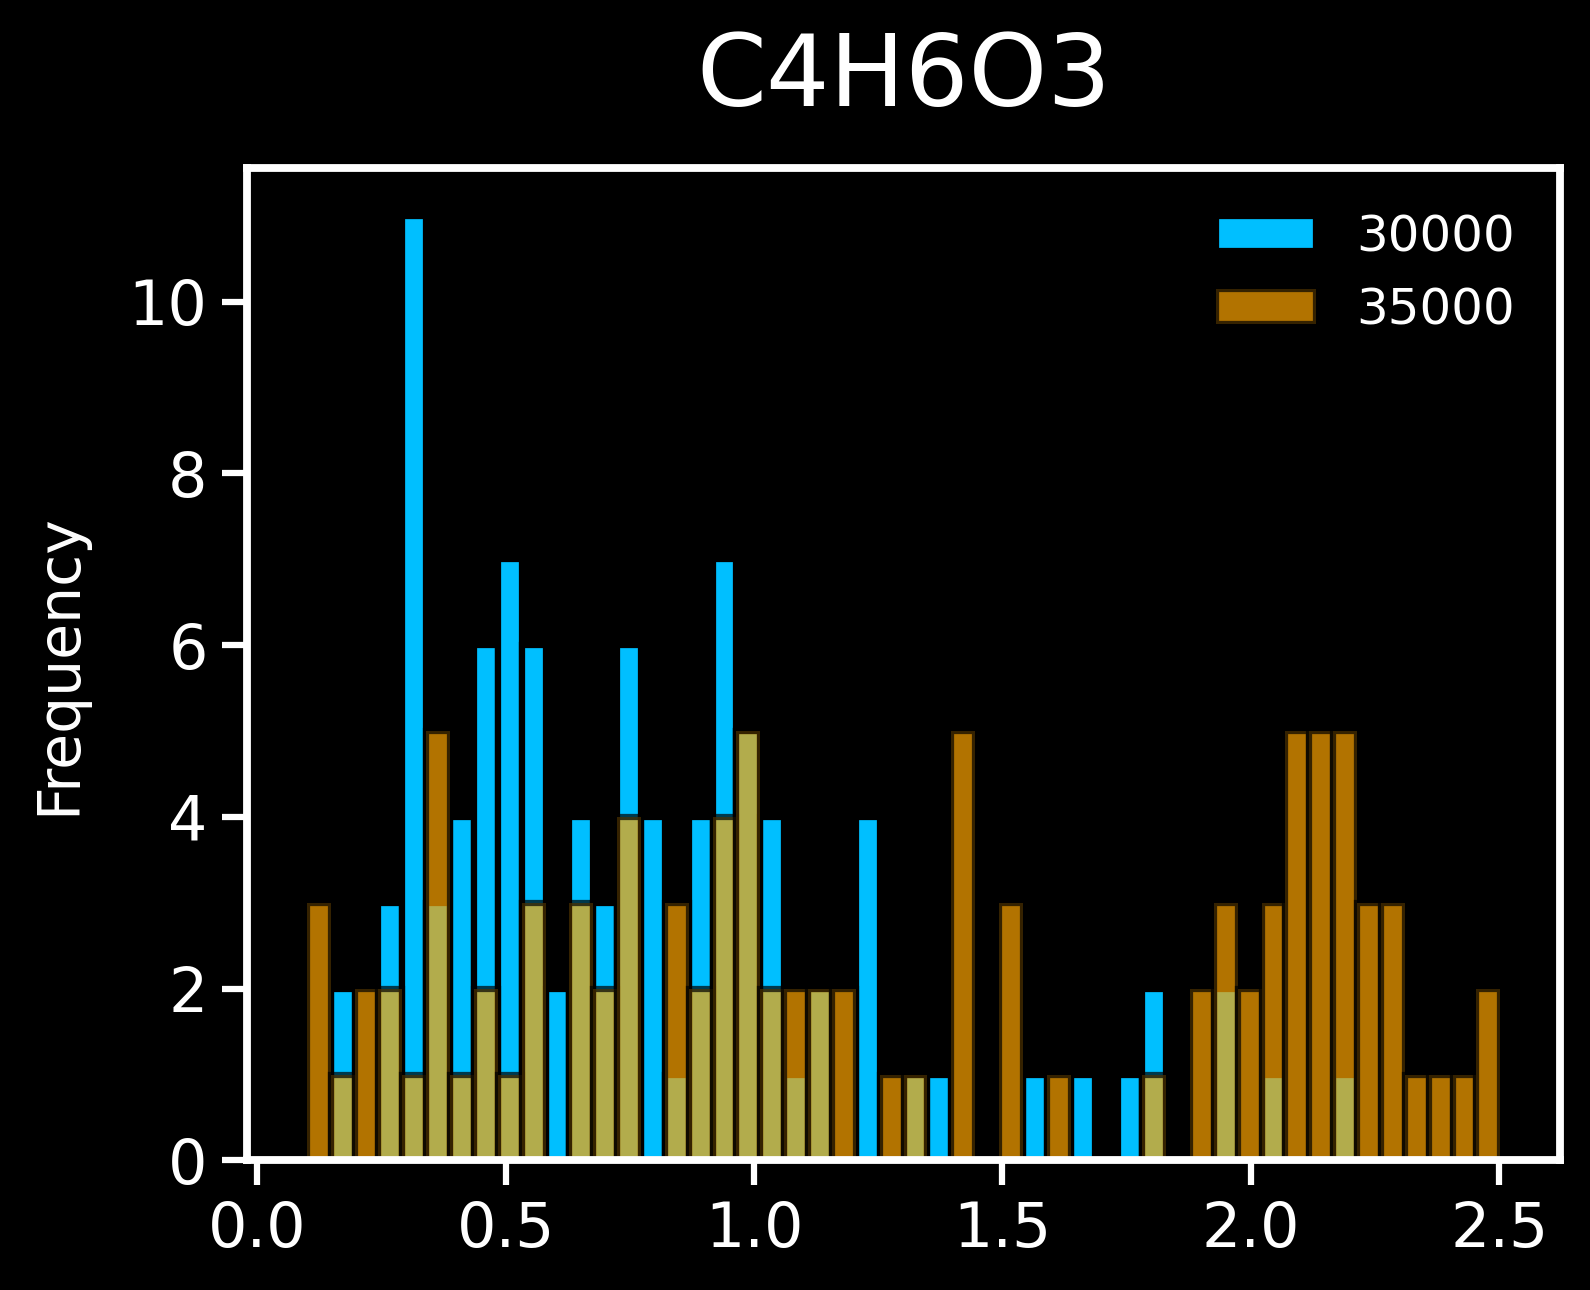

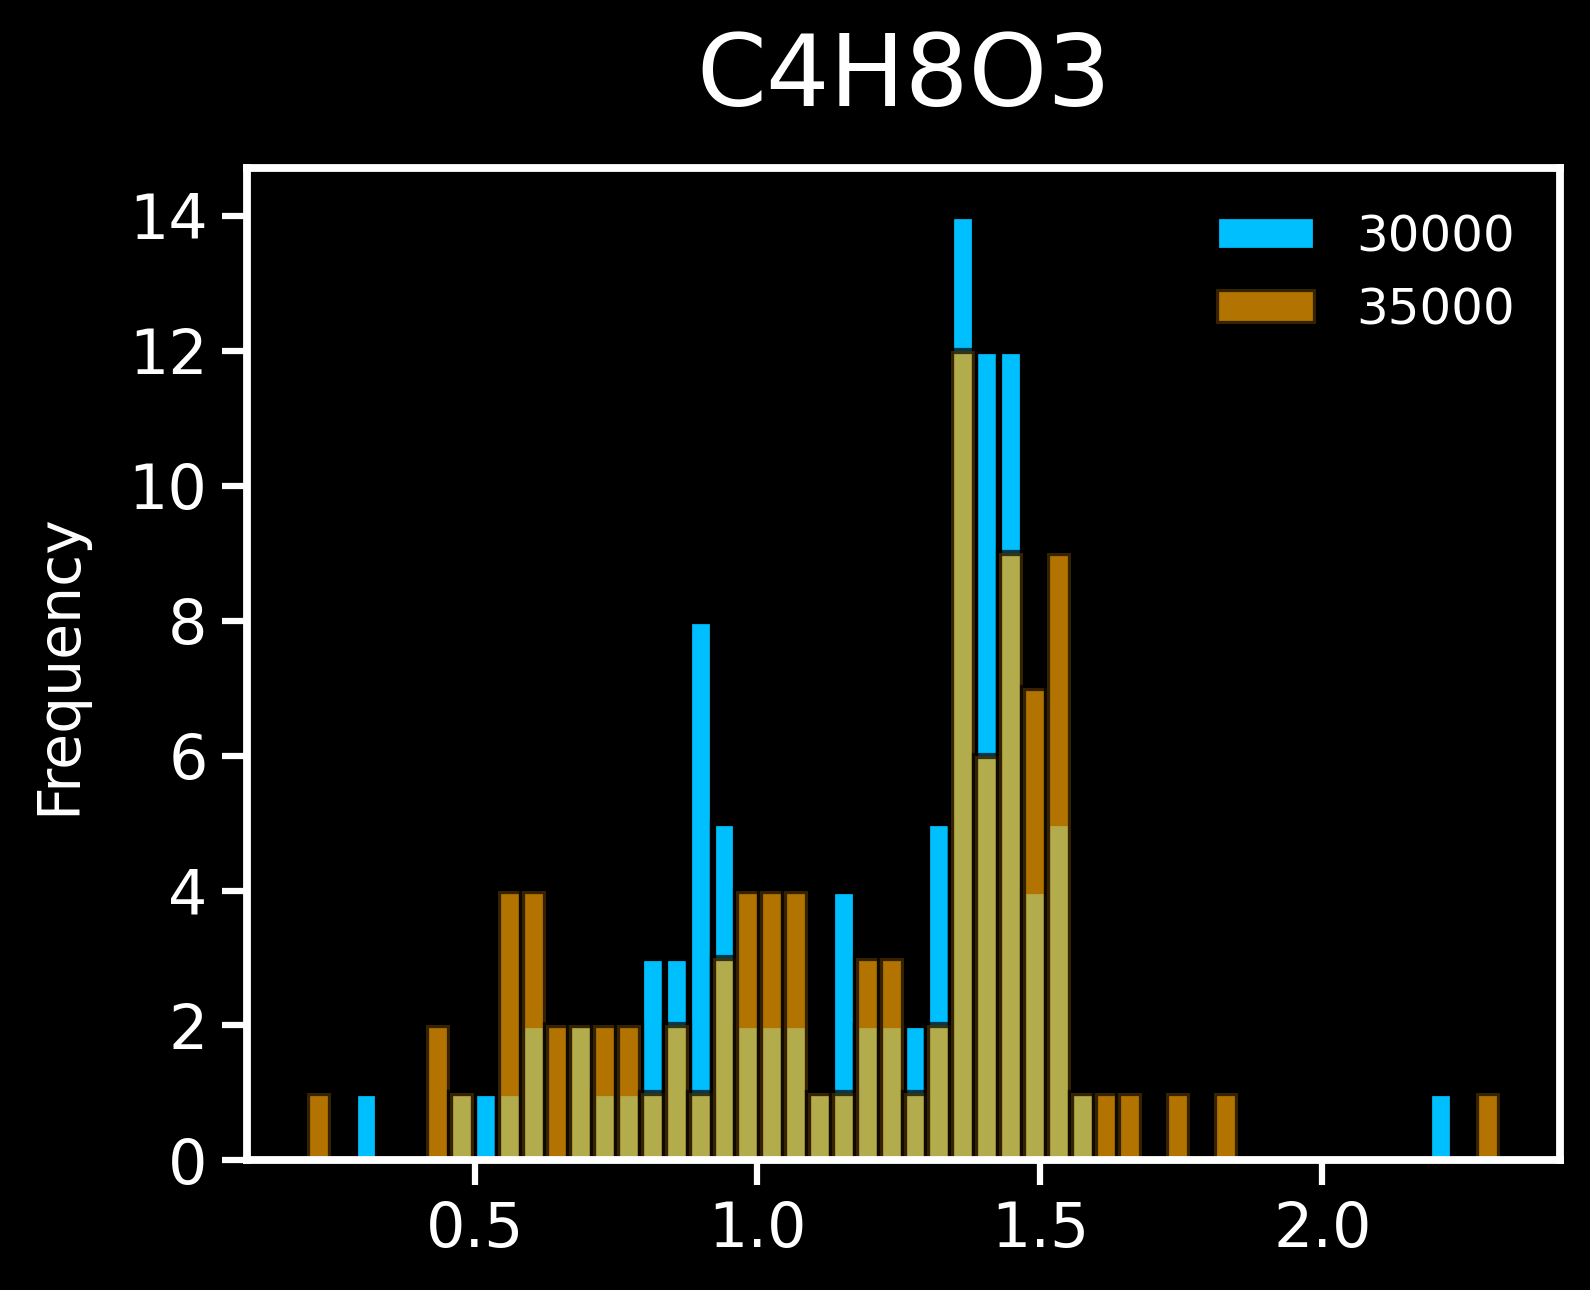

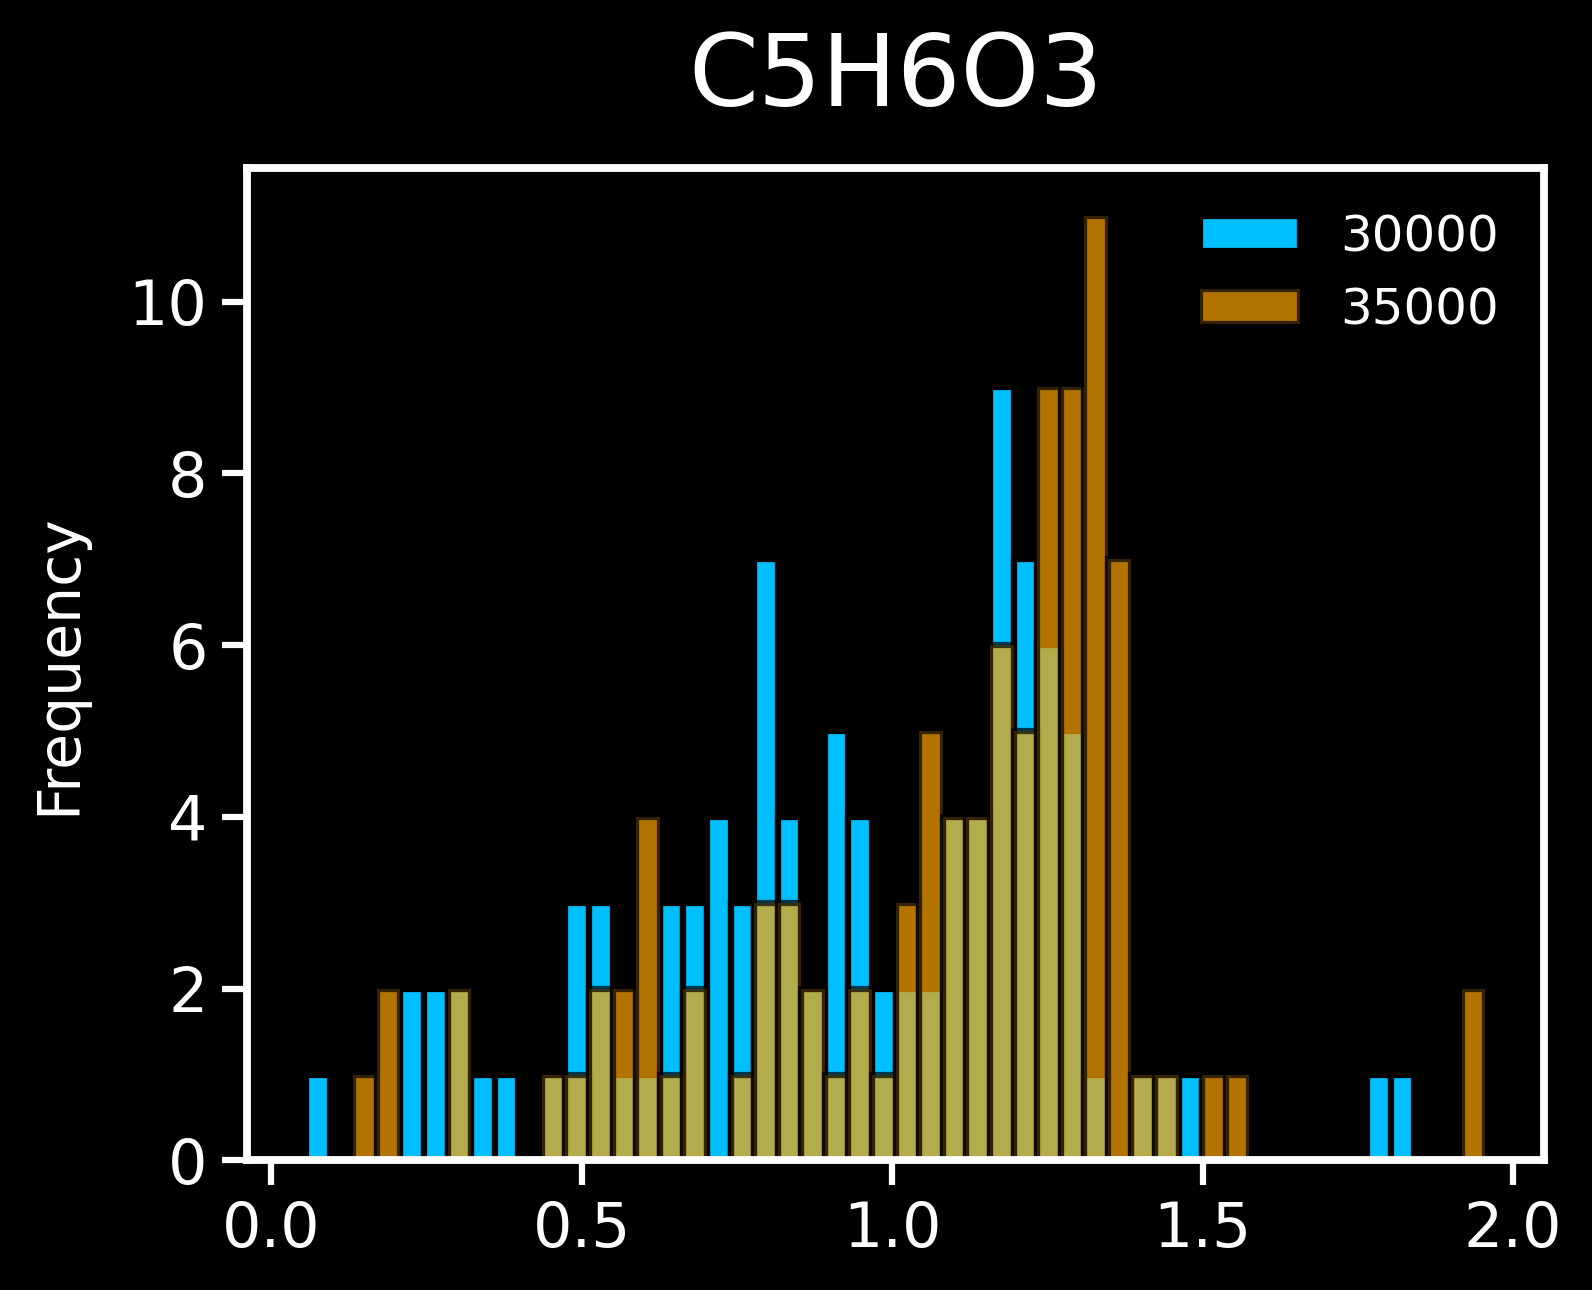

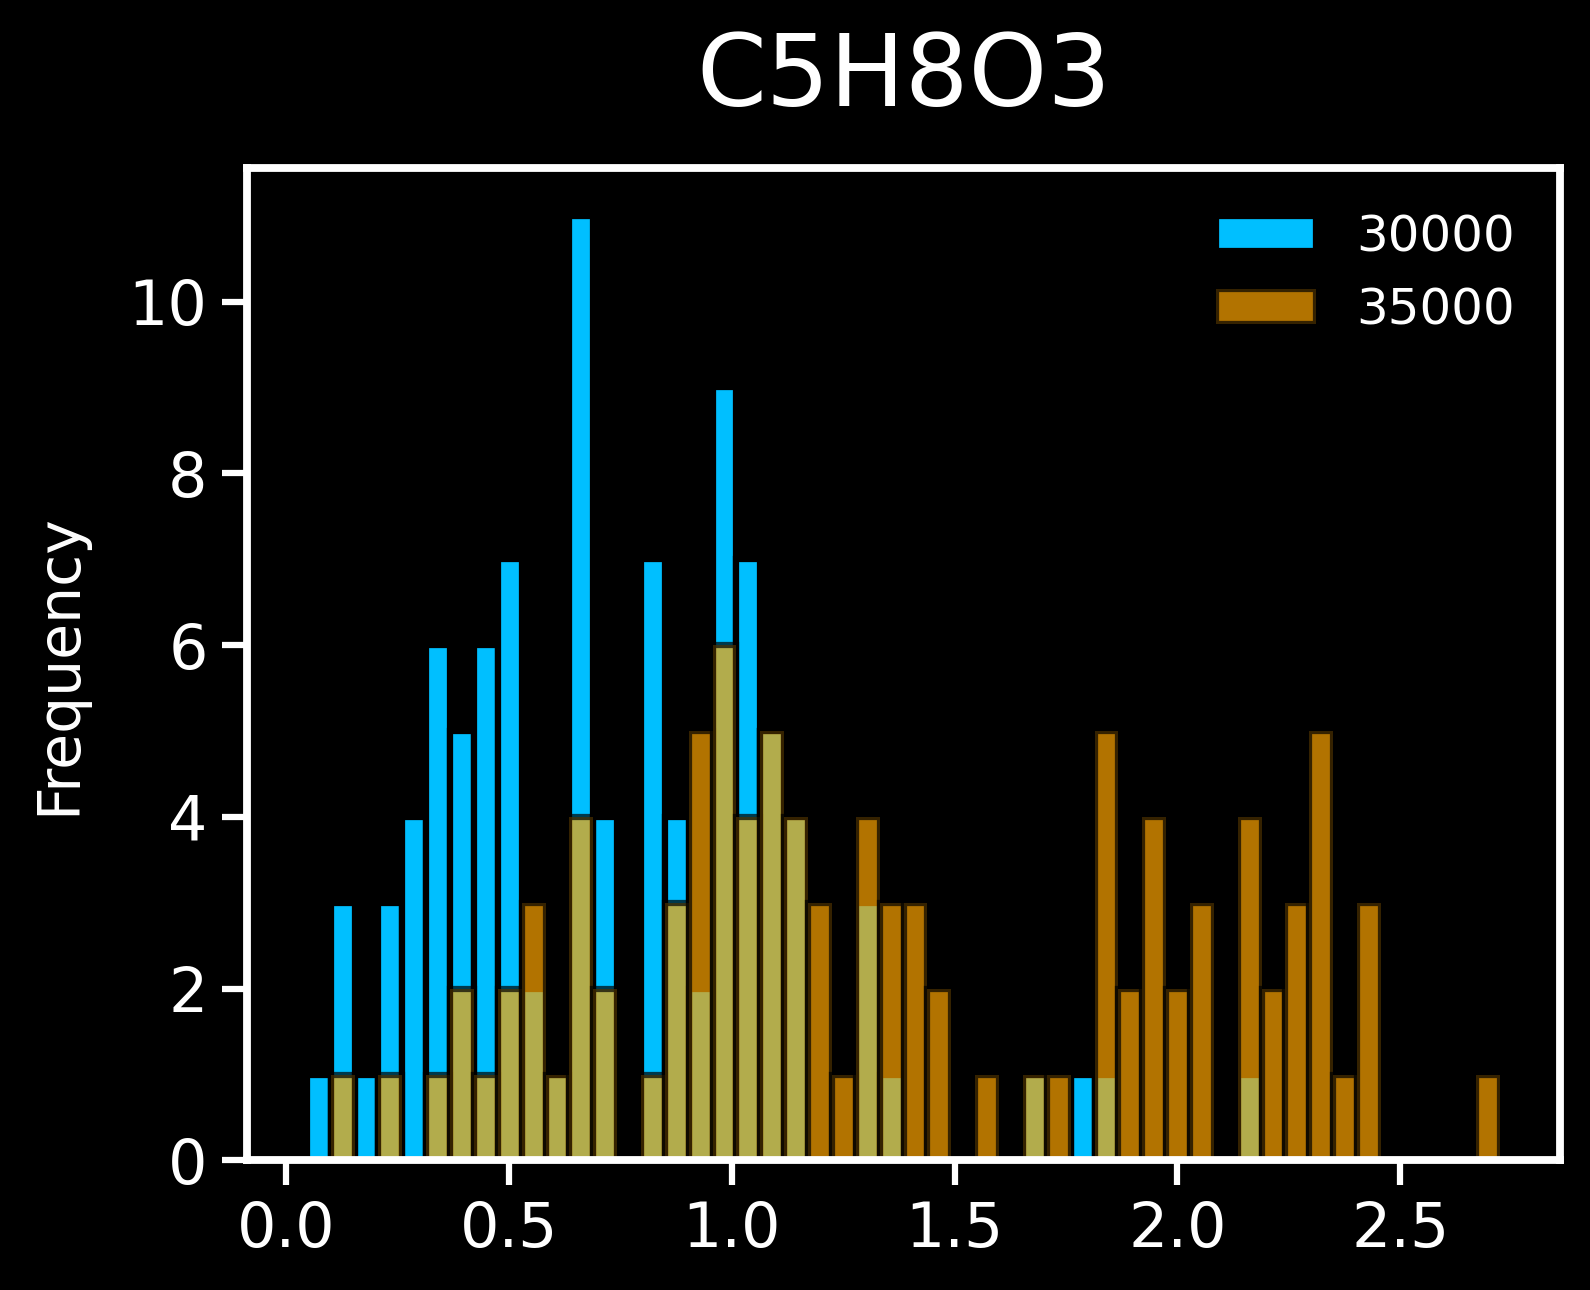

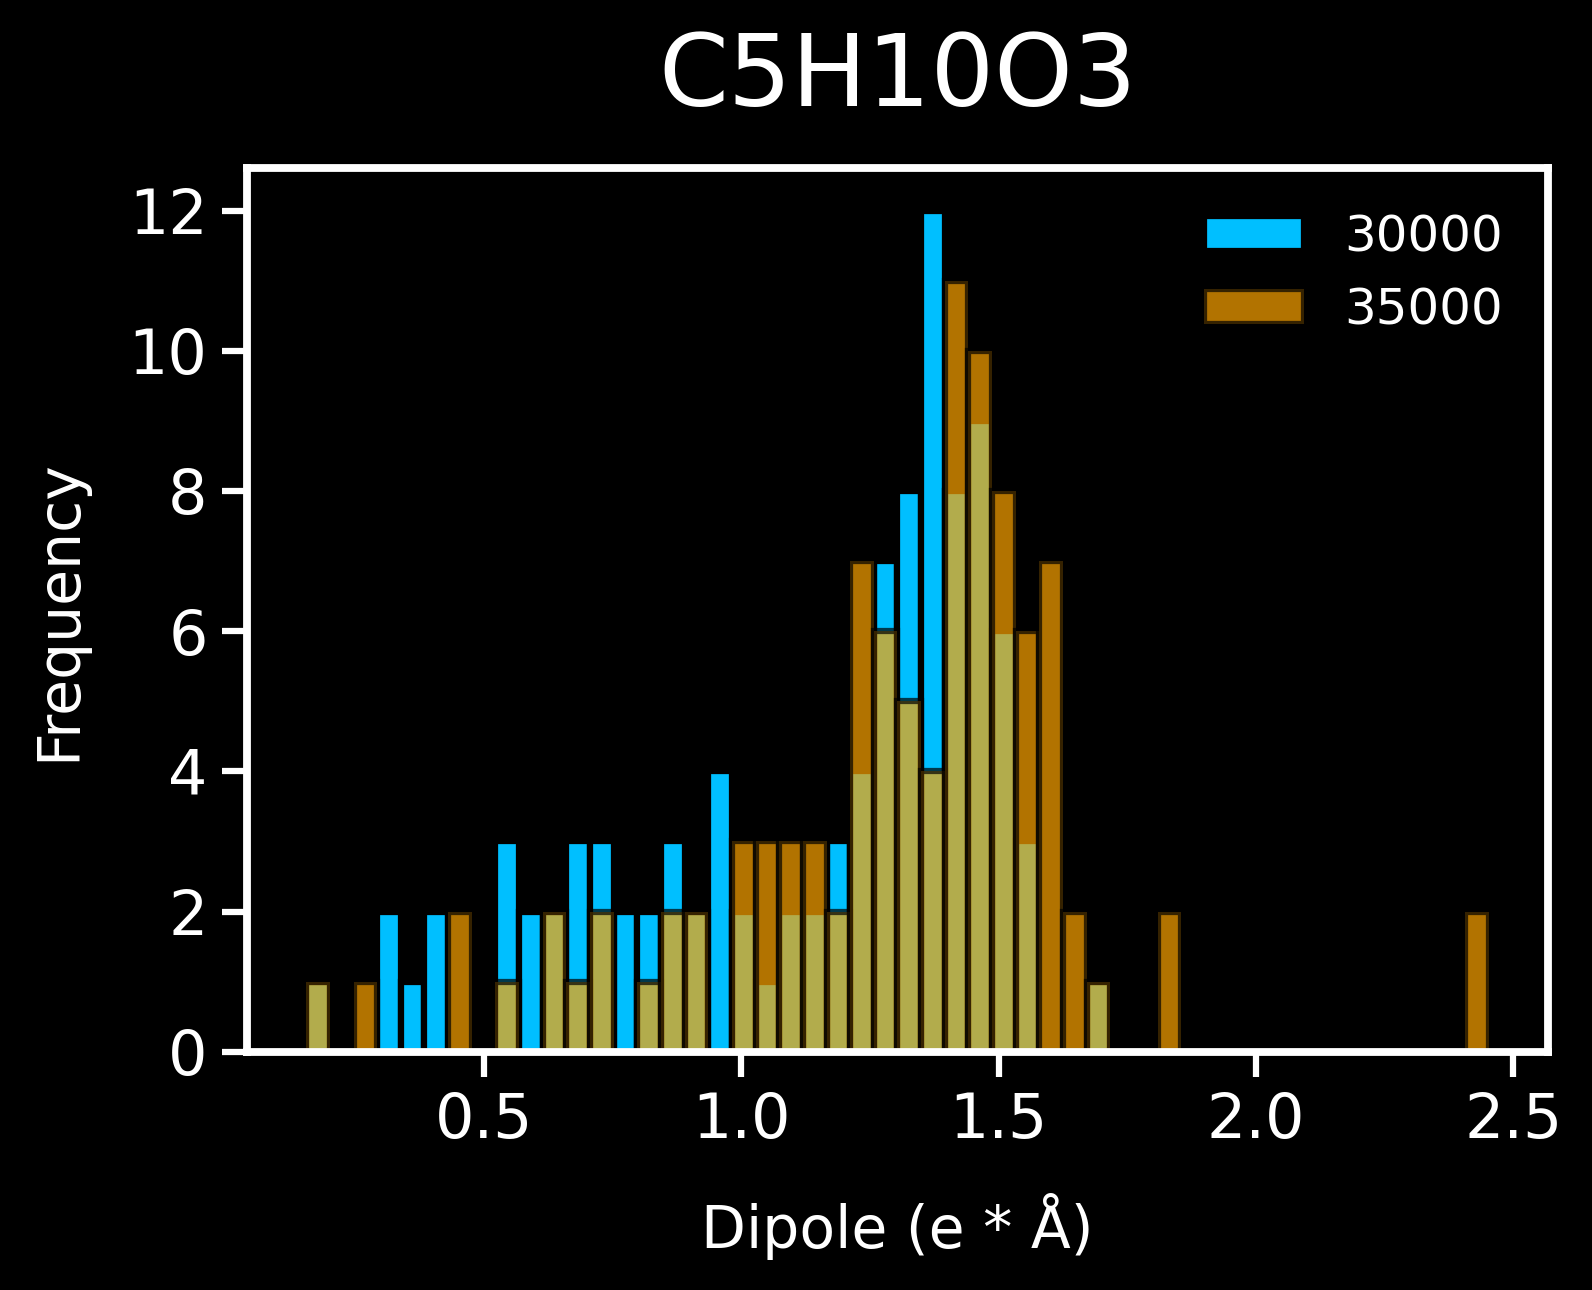

In [ ]:

def get_visuals_dir(base_dir: str, visuals_dir: str) -> Path:
    return Path(f'{base_dir}/{visuals_dir}')


class ImageGridExp1:


    color_tuples = {
        "white": (255, 255, 255),
        "black": (0, 0, 0),
        "grey": (200, 200, 200),
        "red": (255, 0, 0),
        "green": (0, 255, 0),
        "blue": (0, 0, 255),
        "yellow": (255, 255, 0),
    }


    def __init__(
            self,
            agent_data: List[AgentData],
            n_mols: int, 
            save_dir: str,
            eval_formulas: List[str],
            bg_color_str: str,
            smiles_col: str,
            unit: str,
            hist_label: str
    ):
        self.colors = ['#00bfff', 'orange']  # Using deep sky blue instead of regular blue

        self.save_dir = save_dir
        self.agent_data = agent_data
        self.eval_formulas = eval_formulas
        self.n_mols = n_mols
        self.n_rows = len(self.eval_formulas)
        self.n_cols = n_mols * 2 + 1
        self.unit = unit
        self.hist_label = hist_label

        self.smiles_col = smiles_col
        self.img_width = 600
        self.img_height = 600
        self.line_width = 2
        self.gap_height = 20
        self.top_offset = 10

        self.font = ImageFont.truetype("DejaVuSans.ttf", int(np.round(32 * (self.img_width / 300))))  # Increased font size
        self.font_small = ImageFont.truetype("DejaVuSans.ttf", int(np.round(20 * (self.img_width / 300))))
        self.big_bold_font = ImageFont.truetype("DejaVuSans.ttf", int(np.round(40 * (self.img_width / 300))))

        line_color_str = 'white' if bg_color_str == 'black' else 'black'
        self.bg_color = self.color_tuples[bg_color_str] # switch to tuple format
        self.line_color = self.color_tuples[line_color_str]
        self.opposite_line_color = (255 - self.line_color[0], 255 - self.line_color[1], 255 - self.line_color[2])


        self.image_grid = Image.new('RGB', (self.n_cols * self.img_width, self.n_rows * (self.img_height + self.gap_height)), color=self.bg_color)
        self.draw = ImageDraw.Draw(self.image_grid)



    @staticmethod
    def get_image(path_name):
        return Image.open(path_name)
    
    def insert_image_into_grid(self, j, i, img, offset):
        img = img.resize((self.img_width, self.img_height))
        self.image_grid.paste(img, (j * self.img_width, i * (self.img_height + self.gap_height) + offset))

    def insert_black_image_into_grid(self, j, i):
        img = Image.new('RGB', (self.img_width, self.img_height), color=self.bg_color)
        self.image_grid.paste(img, (j * self.img_width, i * (self.img_height + self.gap_height) + self.top_offset))

    def draw_smiles_text(self, j, i, smiles_text, offset=0):
        """ Write SMILES on image """
        x = j * self.img_width + 0.03 * self.img_width
        y = (i - 0.02) * (self.img_height + self.gap_height) + offset
        self.draw.text((x, y), smiles_text, fill=self.line_color, font=self.font_small)

    def draw_text(self, j, i, value, offset=0):
        """ Write value on image """
        text = f"{value:.2f} {self.unit}"
        factor = self.img_width / 300


        # First draw a small rectangle background for the energy text
        box_width = len(text) * 11 * factor
        box_start_x = j * self.img_width + 0.03 * self.img_width

        box_height = 20 * factor
        box_start_y = (i - 0.02)* (self.img_height + self.gap_height) + self.top_offset + 24 * factor + offset
        self.draw.rectangle((box_start_x, box_start_y, box_start_x + box_width, box_start_y + box_height), fill=(*self.opposite_line_color, 128))
        
        # Then write the text on top
        text_x = j * self.img_width + 0.03 * self.img_width
        text_y = (i - 0.02) * (self.img_height + self.gap_height) + self.top_offset + 20 * factor + offset
        self.draw.text((text_x, text_y), text, fill=self.line_color, font=self.font_small)

    def draw_lines(self, i):
        """ Draw horizontal line between rows. """
        if i < self.n_rows - 1:
            self.draw.line(
                [
                    (0, (i + 1-0.05) * (self.img_height + self.gap_height) + self.top_offset), 
                    (self.n_cols * self.img_width, (i + 1 - 0.05) * (self.img_height + self.gap_height) + self.top_offset)
                ], width=self.line_width * (4 if i == 1 else 1), fill='red' if i == 1 else self.line_color
            )

    def plot_molecules(self):
        for i in range(self.n_rows):
            formula = self.eval_formulas[i]
            
            start_col = 0
            for agent_data in self.agent_data:
                for j, j_col in enumerate(range(start_col, start_col + self.n_mols)):
                    path_name = get_visuals_dir(self.save_dir, agent_data.visuals_dir) / f'{formula}_{j}.png'
                    if os.path.exists(path_name):
                        self.insert_image_into_grid(j_col, i, self.get_image(path_name), self.top_offset+20)

                        value_offset = 20 if i == 0 else 0
                        self.draw_text(j_col, i, value=agent_data.top_k[formula][j].dipole_relaxed_f5, offset=value_offset)

                        smiles_offset = 20 if i == 0 else 0
                        self.draw_smiles_text(j_col, i, smiles_text = agent_data.top_k[formula][j].smiles, offset=smiles_offset)
                    else:
                        self.insert_black_image_into_grid(j, i)

                start_col += self.n_mols + 1
            
            self.draw_lines(i)
        

    def save_image_grid(self):
        self.image_grid.save(f'{self.save_dir}/image_grid.png', dpi=(300, 300), quality=95)


    def plot_histograms(self):
        import matplotlib.pyplot as plt
        import seaborn as sns  # only if you want nicer style defaults

        sns.set_context('talk', font_scale=0.9)
        plt.style.use('dark_background')  # instantly elegant dark styling

        j = self.n_mols  # Place histogram in center column

        for i in range(self.n_rows):
            formula = self.eval_formulas[i]
            pretty_formula = build_eval_formulas_pretty()[i]


            # Create figure with high-quality resolution
            fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
            
            # Define monochrome colors for elegance
            alphas = [1.0, 0.70]

            # Get all energies to determine common bin range
            all_values = np.concatenate([agent_data.all_dfs[formula]['dipole'] for agent_data in self.agent_data])
            
            # Create common bins based on all data
            min_value = min(all_values)
            max_value = max(all_values)
            bins = np.linspace(min_value, max_value, 51)  # 20 bins + 1 edge
            

            for idx, agent_data in enumerate(self.agent_data):
                dipole = agent_data.all_dfs[formula]['dipole']
        
                ax.hist(dipole, bins=bins, edgecolor='black', alpha=alphas[idx],
                        color=self.colors[idx], label=agent_data.tag)
            # Set descriptive labels and stylish title
            if i == self.n_rows - 1:
                ax.set_xlabel(self.hist_label, fontsize=14, color='white', labelpad=10)
            
            ax.set_ylabel('Frequency', fontsize=14, color='white', labelpad=10)
            ax.set_title(f'{pretty_formula}', fontsize=24, color='white', pad=15)

            # Enhance ticks and spines visibility
            ax.tick_params(colors='white', direction='out', length=6, width=1.5)
            for spine in ax.spines.values():
                spine.set_edgecolor('white')

            # Refined legend appearance
            legend = ax.legend(frameon=False, fontsize=12, loc='upper right')
            for text in legend.get_texts():
                text.set_color('white')

            # Ensure neat layout
            plt.tight_layout(pad=2.0)

            # Save histogram as image with transparency
            path_name = os.path.join(self.save_dir, f'hist_{formula}.png')
            plt.savefig(path_name, transparent=True, bbox_inches='tight')

            # Insert image into grid
            self.insert_image_into_grid(j, i, self.get_image(path_name), offset=-10 if i != 0 else 5)

    def draw_outer_box(self):

        define_manally = False
        if define_manally:
            num_pixels_x = self.n_cols * self.img_width
            num_pixels_y = self.n_rows * (self.img_height + self.gap_height) + self.top_offset
        else:
            num_pixels_x = self.image_grid.size[0]
            num_pixels_y = self.image_grid.size[1]

        self.draw.rectangle((0, 0, num_pixels_x, num_pixels_y),
                            fill=None, outline='red', width=7)

    def draw_boxes_around_agents(self):
        left1 = 0
        right1 = self.n_mols * self.img_width

        left2 = (self.n_mols + 1) * self.img_width
        right2 = self.image_grid.size[0]

        bottom = self.image_grid.size[1]

        self.draw.rectangle((left1, 0, right1, bottom), fill=None, outline=self.colors[0], width=15)
        self.draw.rectangle((left2, 0, right2, bottom), fill=None, outline=self.colors[1], width=15)

    def write_agent_names(self):

        # Just above bottom
        y = self.image_grid.size[1] - 125

        x1 = (self.n_mols * self.img_width) / 2

        x_end = self.image_grid.size[0]
        x2 = x_end - x1 - 200

        for idx, (agent_data, x_pos) in enumerate(zip(self.agent_data, [x1, x2])):
            self.draw.text((x_pos, y), agent_data.tag, fill=self.colors[idx], font=self.big_bold_font)


agent_list = [agent_data for agent_data in results.values()]

use_dipole = True
if use_dipole:
    unit = 'e·Å'
    hist_label = r'Dipole ($e\,\mathrm{\AA}$)'
else:
    unit = 'eV / atom'
    hist_label = 'Relaxed Energy (eV / atom)'

grid = ImageGridExp1(
    agent_data=agent_list,
    n_mols=n_mols,
    save_dir=base_dir,
    eval_formulas=eval_formulas,
    bg_color_str=bg_color_str,
    smiles_col=smiles_col,
    unit=unit,
    hist_label=hist_label
)

import time

start_time = time.time()
grid.plot_histograms()
print(f"plot_histograms() took {time.time() - start_time:.2f} seconds")

start_time = time.time()
grid.plot_molecules()
print(f"plot_molecules() took {time.time() - start_time:.2f} seconds")

start_time = time.time()
grid.draw_outer_box()
print(f"draw_outer_box() took {time.time() - start_time:.2f} seconds")

start_time = time.time()
grid.write_agent_names()
print(f"write_agent_names() took {time.time() - start_time:.2f} seconds")

# Uncomment if you want to time draw_boxes_around_agents
# start_time = time.time()
# grid.draw_boxes_around_agents()
# print(f"draw_boxes_around_agents() took {time.time() - start_time:.2f} seconds")

start_time = time.time()
grid.save_image_grid()
print(f"save_image_grid() took {time.time() - start_time:.2f} seconds")

### Create a image grid of molecules. 

In [110]:
import plotly.graph_objects as go

def energy_histogram_numpy(df, column_name='abs_energy'):
    """Plot the energy histogram of a dataframe"""

    # only use rows where column_name is not null/None/NaN
    # df = df.dropna(subset=[column_name])

    df['valid'] = df['valid'].astype(bool)

    # Filter data for valid and invalid categories
    valid_energies = df[df['valid']][column_name].values
    invalid_energies = df[~df['valid']][column_name].values

    print(f"len(valid_energies): {len(valid_energies)}")
    print(f"len(invalid_energies): {len(invalid_energies)}")

    # Calculate the bin edges using np.linspace
    energy_range = (min(df[column_name]), max(df[column_name]))

    print(f"energy_range: {energy_range}")

    # num_bins = int((energy_range[1] - energy_range[0]) / bin_size) + 1
    # energy_unit = 'eV'
    # if energy_unit == 'Hartree':
    #     width = 0.007
    #     bin_size = 0.01
    # elif energy_unit == 'eV':
    #     width = 0.15
    #     bin_size = 0.23

    num_bins = 50
    bins = np.linspace(energy_range[0], energy_range[1], num_bins)
    bin_size = bins[1] - bins[0]

    print(f"bins: {bins}")
    width = bin_size * 0.75
    opacity = 0.5

    # Check if there's data in each category before creating the plot
    if len(valid_energies) > 0 and len(invalid_energies) > 0:
        # Create histograms manually for both categories
        valid_hist, valid_bins = np.histogram(valid_energies, bins=bins)
        invalid_hist, invalid_bins = np.histogram(invalid_energies, bins=bins)

        # Create a custom plot with Plotly
        trace1 = go.Bar(
            x=valid_bins,
            y=valid_hist,
            name='Valid',
            opacity=1,
            width=width,
            marker=dict(color='navy')
        )
        trace2 = go.Bar(
            x=invalid_bins,
            y=invalid_hist,
            name='Invalid',
            opacity=opacity,
            width=width,
            marker=dict(color='orange')
        )

        layout = go.Layout(
            title='Energy Histogram',
            xaxis=dict(title='Energy'),
            yaxis=dict(title='Counts')
        )

        data = [trace1, trace2]
        fig = go.Figure(data=data, layout=layout)

        # Adjust bargap and bargroupgap to control the bar width
        fig.update_layout(bargap=0.1, bargroupgap=0.1)

    else:
        if len(valid_energies) > 0:
            # Create a histogram for the 'Valid' category
            valid_hist, valid_bins = np.histogram(valid_energies, bins=bins)
            trace1 = go.Bar(
                x=valid_bins,
                y=valid_hist,
                name='Valid',
                opacity=opacity,
                width=width,
                marker=dict(color='blue')
            )
            layout = go.Layout(
                title='Valid Energy Histogram',
                xaxis=dict(title='Energy'),
                yaxis=dict(title='Counts')
            )
            fig = go.Figure(data=[trace1], layout=layout)

            # Adjust bargap and bargroupgap to control the bar width
            fig.update_layout(bargap=0.2, bargroupgap=0.1)

        if len(invalid_energies) > 0:
            # Create a histogram for the 'Invalid' category
            invalid_hist, invalid_bins = np.histogram(invalid_energies, bins=bins)
            trace2 = go.Bar(
                x=invalid_bins,
                y=invalid_hist,
                name='Invalid',
                opacity=opacity,
                width=width,
                marker=dict(color='orange')
            )
            layout = go.Layout(
                title='Invalid Energy Histogram',
                xaxis=dict(title='Energy'),
                yaxis=dict(title='Counts')
            )
            fig = go.Figure(data=[trace2], layout=layout)

            # Adjust bargap and bargroupgap to control the bar width
            fig.update_layout(bargap=0.2, bargroupgap=0.1)

    return fig


In [111]:
agent_data = results['entropy-schedule-AV']

df = agent_data.all_dfs[eval_formulas[0]].copy()




In [112]:
fig = energy_histogram_numpy(df, column_name='e_relaxed')

# Plotly
fig.show()

# Matplotlib
fig.write_html('energy_histogram.html')



len(valid_energies): 22538
len(invalid_energies): 7392
energy_range: (nan, nan)
bins: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan]


ValueError: 
    Invalid value of type 'numpy.float64' received for the 'width' property of bar
        Received value: nan

    The 'width' property is a number and may be specified as:
      - An int or float in the interval [0, inf]
      - A tuple, list, or one-dimensional numpy array of the above

In [103]:

df['valid'] = df['valid'].astype(bool)

# Filter data for valid and invalid categories
valid_energies = df[df['valid']]['e_relaxed'].values
invalid_energies = df[~df['valid']]['e_relaxed'].values

print(f"len(valid_energies): {len(valid_energies)}")
print(f"len(invalid_energies): {len(invalid_energies)}")



len(valid_energies): 22538
len(invalid_energies): 7392


NameError: name 'ImageGridExp1' is not defined